# HealthConnect Week 5: Data Preparation and Baseline Modelling
**Wilson Moses | AnalystLab Africa | Data Science Track | Batch D**

## 1. My Week 4 foundation and Week 5 objective
I continue the same fictional HealthConnect project and preserve the raw sources. Week 4 defined appointment-level no-show prediction; this week I implement preparation, visual evidence, feature engineering and baseline evaluation. No-Show is 1, Attended is 0; cancellations remain preserved but are excluded from this conditional binary experiment. Future cancellations are unknown at booking, so this is not yet a complete all-bookings service.

I refine the prediction point to booking time. I exclude reminders and waiting time because their availability then is unverified. Supplied history counts are provisionally assumed to describe history before booking, not reconstructed from unreliable patient IDs. I use a fixed chronological cutoff, without tuning on the held-out outcomes.

References: Week 4 Problem Definition Report sections 3-9; Week 4 Project Summary; Week 5 assignment, Data Science Track tasks 1-6. IBM stages: Business Understanding and Analytical Approach.

**Reproducibility:** run all cells top to bottom from this folder or the package root. Output CSVs contain fictional records only. Existing generated Week 5 outputs are replaced on rerun; raw files are never written. The saved outputs were generated by sequential Python execution in one clean namespace, not by a Jupyter kernel.

## 2. Load an auditable source
I use pathlib for portable paths and Pandas for tables. `keep_default_na=False` preserves the meaningful reminder category `None`. Only explicit blanks are later converted to missing values. A SHA-256 digest records source identity; matching dimensions alone cannot prove two files are identical. IBM: Data Collection.

In [1]:
from pathlib import Path
import hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.calibration import calibration_curve

BASE = Path.cwd() if (Path.cwd()/'data/raw').is_dir() else Path.cwd().parent
SOURCE = BASE/'data/raw/HealthConnect_Appointment_Data.csv'
assert SOURCE.is_file(), 'Run from the notebook folder or package root.'
FIG = BASE/'outputs/figures'; MET = BASE/'outputs/metrics'
FIG.mkdir(parents=True, exist_ok=True); MET.mkdir(parents=True, exist_ok=True)
df_raw = pd.read_csv(SOURCE, keep_default_na=False)
df = df_raw.copy()
source_hash = hashlib.sha256(SOURCE.read_bytes()).hexdigest()
print('Source SHA-256:', source_hash)
print('Shape:', df.shape)
print('Python:', platform.python_version(), 'Pandas:', pd.__version__, 'sklearn:', sklearn.__version__)
plt.rcParams.update({'figure.figsize': (8,4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
def savefig(name):
    plt.tight_layout(); plt.savefig(FIG/name, dpi=180, bbox_inches='tight'); plt.show()


Source SHA-256: 1f2c40ae14833b46fe6e1a353446a0e038f19ae06434b37d98545b3e28697137
Shape: (5000, 18)
Python: 3.12.13 Pandas: 2.2.3 sklearn: 1.8.0


## 3. Type conversion and data-quality controls
I explicitly parse month/day/year dates and numerical blanks. `errors='coerce'` makes invalid values visible as NaT/NaN; it is not a silent repair. Assertions stop the workflow on invalid dates, inconsistent history counts or unexpected target labels. I retain Sundays because the source conflict is unresolved, and do not invent replacement ages or remove plausible outliers. IBM: Data Understanding and Preparation.

In [2]:
numeric = ['age','booking_lead_days','previous_appointments','previous_no_shows',
           'distance_to_clinic_km','waiting_time_minutes']
parse_failures = {}
for col in ['booking_date','appointment_date']:
    df[col] = pd.to_datetime(df[col], format='%m/%d/%Y', errors='coerce')
    parse_failures[col] = int(df[col].isna().sum())
for col in numeric:
    original = df[col].replace('', np.nan)
    df[col] = pd.to_numeric(original, errors='coerce')
    parse_failures[col] = int((original.notna() & df[col].isna()).sum())
quality = pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum(),
                       'missing_pct':df.isna().mean()*100, 'unique':df.nunique(dropna=False)})
quality.to_csv(MET/'data_quality.csv', index_label='variable')
age_span = df.groupby('patient_id')['age'].agg(lambda s: s.max()-s.min())
audit = {'rows':len(df), 'columns':df.shape[1], 'patients':df.patient_id.nunique(),
 'duplicate_rows':int(df.duplicated().sum()),
 'duplicate_appointment_ids':int(df.appointment_id.duplicated().sum()),
 'sundays':int(df.appointment_date.dt.dayofweek.eq(6).sum()),
 'patient_ids_age_span_gt2':int(age_span.gt(2).sum()),
 'lead_mismatches':int(((df.appointment_date-df.booking_date).dt.days != df.booking_lead_days).sum()),
 'weekday_mismatches':int(df.appointment_date.dt.day_name().ne(df.appointment_day).sum())}
assert not any(parse_failures.values()), parse_failures
assert audit['duplicate_rows']==audit['duplicate_appointment_ids']==0
assert audit['lead_mismatches']==0
assert df.appointment_date.ge(df.booking_date).all()
assert df.previous_no_shows.le(df.previous_appointments).all()
assert (df[numeric].ge(0) | df[numeric].isna()).all().all()
assert set(df.appointment_outcome)=={'Attended','No-Show','Cancelled'}
print(quality.to_string()); print(json.dumps(audit, indent=2))
print(pd.crosstab(df.reminder_sent,df.reminder_channel).to_string())


                                dtype  missing  missing_pct  unique
appointment_id                 object        0          0.0    5000
patient_id                     object        0          0.0    1696
gender                         object        0          0.0       3
age                             int64        0          0.0      63
age_group                      object        0          0.0       6
appointment_type               object        0          0.0       4
booking_date           datetime64[ns]        0          0.0     593
appointment_date       datetime64[ns]        0          0.0     545
appointment_day                object        0          0.0       7
appointment_time               object        0          0.0       3
booking_lead_days               int64        0          0.0      61
previous_appointments           int64        0          0.0      12
previous_no_shows               int64        0          0.0       6
reminder_sent                  object        0  

## 4. Target, cohort and split BEFORE model-directed exploration
I retain only Attended and No-Show for the first experiment and map labels explicitly. My fixed cutoff is 1 March 2026, chosen as a calendar boundary for a roughly last-four-month prospective test, not for a favourable score. Training outcomes must occur before it; test bookings must occur on or after it. Appointments booked earlier but completed after the cutoff are purged because their outcomes would not be available at training time. This is stricter than simply sorting appointment dates. I inspect model-directed plots only on training data. Week 4 report: time split and cancellation decisions; IBM: Preparation/Evaluation design.

In [3]:
cohort = df.loc[df.appointment_outcome.isin(['Attended','No-Show'])].copy()
cohort['no_show_flag'] = cohort.appointment_outcome.map({'Attended':0,'No-Show':1}).astype('int8')
CUTOFF = pd.Timestamp('2026-03-01')
cohort['split'] = np.select([cohort.appointment_date.lt(CUTOFF), cohort.booking_date.ge(CUTOFF)],
                            ['train','test'], default='purged')
train = cohort.loc[cohort.split.eq('train')].copy()
test = cohort.loc[cohort.split.eq('test')].copy()
assert train.appointment_date.max() < test.booking_date.min()
assert set(train.appointment_id).isdisjoint(test.appointment_id)
assert train.no_show_flag.nunique()==test.no_show_flag.nunique()==2
split_table = cohort.groupby('split').agg(records=('appointment_id','size'),
                   no_show_rate=('no_show_flag','mean'))
split_table.to_csv(MET/'split_summary.csv')
patient_overlap = len(set(train.patient_id) & set(test.patient_id))
print(split_table.to_string()); print('Overlapping patient IDs:',patient_overlap)
print('Training completed through:',train.appointment_date.max())
print('Testing booked from:',test.booking_date.min())
print('Cancellations excluded:', len(df)-len(cohort))


        records  no_show_rate
split                        
purged      256      0.601562
test        799      0.484355
train      3682      0.511135
Overlapping patient IDs: 579
Training completed through: 2026-02-28 00:00:00
Testing booked from: 2026-03-01 00:00:00
Cancellations excluded: 263


### Split interpretation and limitations
Some patient IDs occur on both sides: this estimates later appointments in a mixed returning/new-patient population, not unseen-patient generalisation. ID inconsistencies mean a separate patient-group experiment and source clarification remain necessary. The data end at June 2026, so later bookings with long future lead times may be absent: the test is limited to observed completed appointments. I do not shuffle, balance or oversample the test set.

## 5. Visual evidence on training records
I examine distributions to decide whether to scale, impute or investigate outliers; I inspect category rates with counts to avoid mistaking small samples for stable effects. I do not infer that a reminder or demographic category causes attendance. IBM: Data Understanding.

                         size      mean
appointment_type                       
Diagnostic Test           427  0.512881
Follow-up                1049  0.525262
General Consultation     1551  0.497743
Specialist Consultation   655  0.519084
       booking_lead_days  distance_to_clinic_km
count        3682.000000            3623.000000
mean           29.465508              10.177367
std            17.355090               6.692504
min             0.000000               0.500000
25%            14.000000               5.300000
50%            29.000000               8.700000
75%            44.000000              13.500000
max            60.000000              45.000000


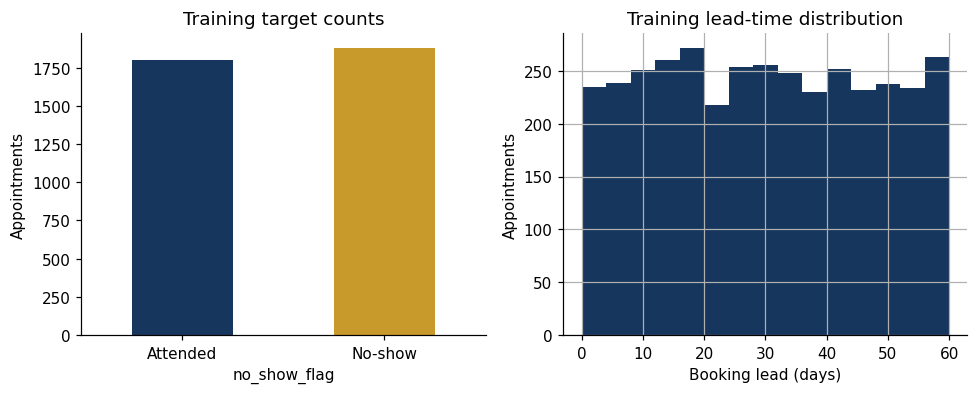

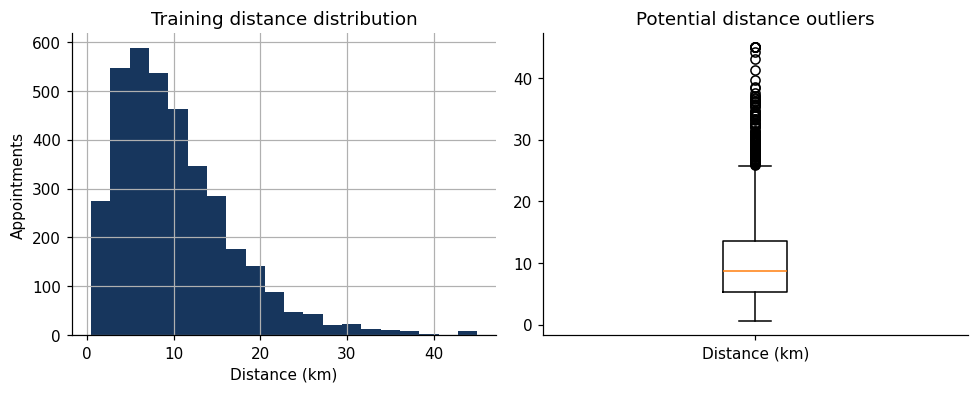

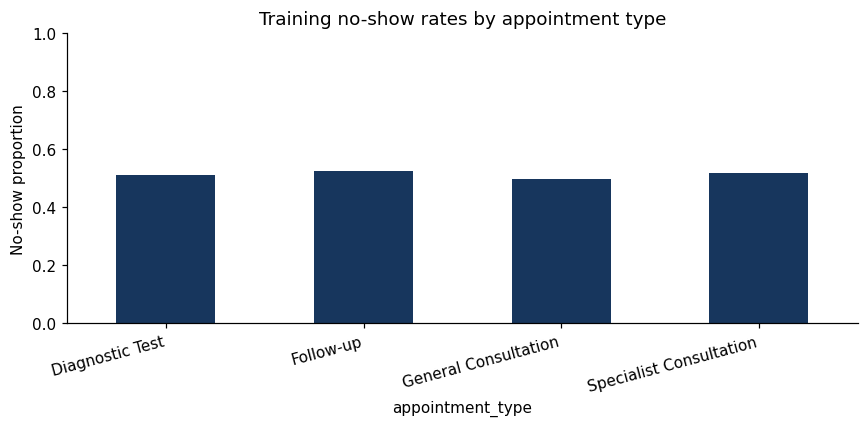

In [4]:
fig, axes = plt.subplots(1,2,figsize=(9,3.7))
train.no_show_flag.value_counts().sort_index().plot.bar(ax=axes[0],color=['#17365D','#C79A2B'])
axes[0].set(xticklabels=['Attended','No-show'],ylabel='Appointments',title='Training target counts')
axes[0].tick_params(axis='x',rotation=0)
train.booking_lead_days.hist(ax=axes[1],bins=15,color='#17365D')
axes[1].set(xlabel='Booking lead (days)',ylabel='Appointments',title='Training lead-time distribution')
savefig('01_target_lead.png')
fig, axes = plt.subplots(1,2,figsize=(9,3.7))
train.distance_to_clinic_km.hist(ax=axes[0],bins=20,color='#17365D')
axes[0].set(xlabel='Distance (km)',ylabel='Appointments',title='Training distance distribution')
axes[1].boxplot([train.distance_to_clinic_km.dropna()],tick_labels=['Distance (km)'])
axes[1].set(title='Potential distance outliers')
savefig('02_distance.png')
rates = train.groupby('appointment_type').no_show_flag.agg(['size','mean'])
print(rates.to_string()); rates.to_csv(MET/'training_type_rates.csv')
rates['mean'].plot.bar(color='#17365D')
plt.ylabel('No-show proportion'); plt.ylim(0,1); plt.xticks(rotation=15,ha='right')
plt.title('Training no-show rates by appointment type')
savefig('03_type_rates.png')
print(train[['booking_lead_days','distance_to_clinic_km']].describe().to_string())


### My preparation decisions
The two target classes both have substantial support, so I keep the natural distribution and use no class balancing for this first baseline. I retain plausible nonnegative distances; boxplot flags are investigation signals, not automatic deletion rules. Median imputation accommodates missing distances, while standardisation puts numerical features on comparable scales for regularised logistic regression. Category differences motivate encoding appointment type but do not prove causation or predictive value on new data.

## 6. Feature engineering and eligibility
I engineer prior_no_show_rate = previous_no_shows / previous_appointments; for zero history I use 0 plus a separate no_prior_history flag so 'no evidence' can be distinguished from perfect attendance. I create is_weekend from the scheduled date (known at booking) and log_lead_days = log(1 + booking_lead_days), an a priori nonlinear representation that tolerates zero-day bookings. Its benefit is a hypothesis, not established by this single experiment. I replace the raw lead with its log and omit redundant age groups/day labels. Gender is reserved for error auditing rather than prediction. I retain age, subject to fairness review. History counts are used only under the explicit as-of-booking assumption; no ID-derived history is constructed.

In [5]:
def engineer(frame):
    out = frame.copy()
    out['prior_no_show_rate'] = out.previous_no_shows.div(out.previous_appointments.replace(0,np.nan)).fillna(0)
    out['no_prior_history'] = out.previous_appointments.eq(0).astype(int)
    out['is_weekend'] = out.appointment_date.dt.dayofweek.ge(5).astype(int)
    out['log_lead_days'] = np.log1p(out.booking_lead_days)
    return out
cohort = engineer(cohort)
train = cohort.loc[cohort.split.eq('train')].copy()
test = cohort.loc[cohort.split.eq('test')].copy()
num_features = ['age','distance_to_clinic_km','previous_appointments','prior_no_show_rate',
                'no_prior_history','is_weekend','log_lead_days']
cat_features = ['appointment_type','appointment_time']
features = num_features + cat_features
X_train, y_train = train[features], train.no_show_flag
X_test, y_test = test[features], test.no_show_flag
assert not set(features) & {'appointment_id','patient_id','appointment_outcome','reminder_sent',
                           'reminder_channel','waiting_time_minutes','no_show_flag'}
cohort.to_csv(BASE/'data/processed/HealthConnect_Week5_Modelling_Cohort.csv',index=False)
print('Features:',features)
print(train[['prior_no_show_rate','no_prior_history','is_weekend','log_lead_days']].head().to_string())


Features: ['age', 'distance_to_clinic_km', 'previous_appointments', 'prior_no_show_rate', 'no_prior_history', 'is_weekend', 'log_lead_days', 'appointment_type', 'appointment_time']
   prior_no_show_rate  no_prior_history  is_weekend  log_lead_days
0            0.000000                 0           0       2.564949
1            0.000000                 0           0       1.098612
2            0.200000                 0           0       3.663562
3            0.333333                 0           0       3.737670
4            0.333333                 0           0       3.871201


## 7. Training-only preprocessing and baseline fitting
ColumnTransformer applies median imputation plus StandardScaler to numerical columns, and most-frequent imputation plus OneHotEncoder to categorical columns. Pipeline fits these steps only on training data. Unknown future categories are ignored rather than crashing; they still need monitoring. I compare a most-frequent DummyClassifier with logistic regression (C=1, max_iter=2000), with no hyperparameter search. A fixed 0.5 threshold is a technical reference, not a clinic-approved workload threshold. IBM: Preparation and Modelling.

In [6]:
prep = ColumnTransformer([
 ('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num_features),
 ('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),
                 ('encode',OneHotEncoder(handle_unknown='ignore'))]),cat_features)])
model = Pipeline([('prep',prep),('classifier',LogisticRegression(C=1.0,max_iter=2000,random_state=42))])
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train,y_train)
model.fit(X_train,y_train)
print('Training records:',len(train),'Test records:',len(test))
print('Logistic iterations:',model.named_steps['classifier'].n_iter_)
print('Numeric training medians:',model.named_steps['prep'].named_transformers_['num'].named_steps['impute'].statistics_)


Training records: 3682 Test records: 799
Logistic iterations: [9]
Numeric training medians: [49.          8.7         3.          0.          0.          0.
  3.40119738]


## 8. Held-out evaluation
Recall measures the fraction of actual no-shows flagged; precision measures how many flagged appointments actually became no-shows. F1 balances the two. ROC-AUC assesses ranking; average precision summarises the precision-recall curve (not trapezoidal PR-AUC). Brier score measures squared probability error. I report all values rather than selecting only the strongest metric. Test outcomes are used here for evaluation, not to revise this baseline.

                     accuracy  precision  recall      f1  roc_auc  average_precision   brier   tn   fp   fn   tp  flagged
model                                                                                                                    
Dummy                  0.4844     0.4844  1.0000  0.6526   0.5000             0.4844  0.5156    0  412    0  387      799
Logistic regression    0.6083     0.5885  0.6357  0.6112   0.6678             0.6586  0.2290  240  172  141  246      418


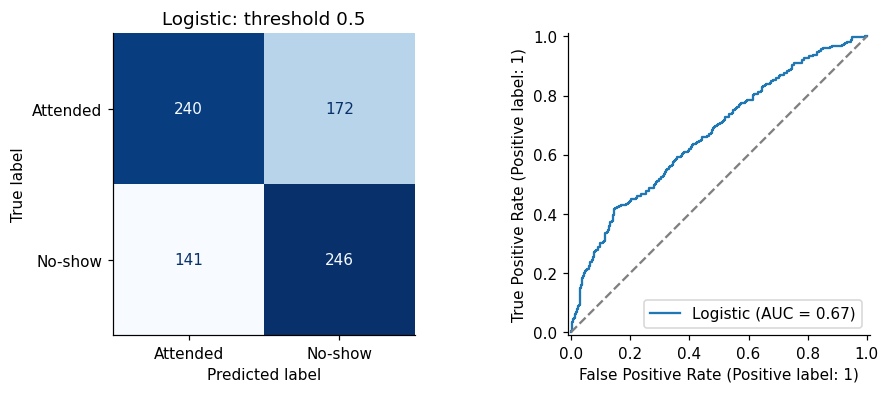

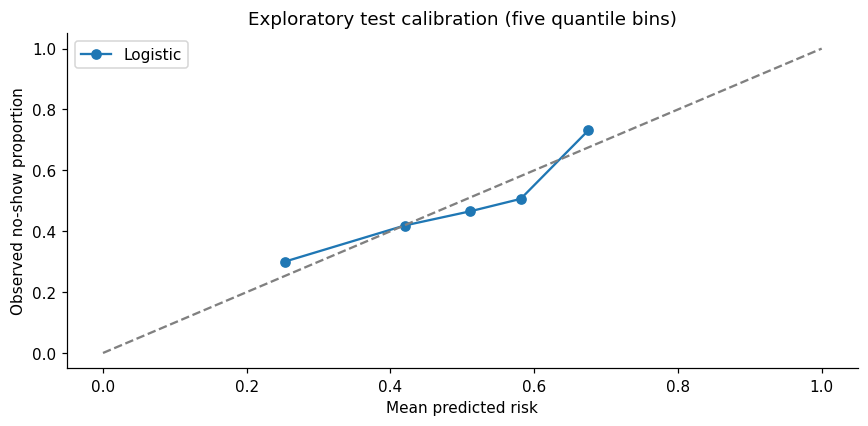

In [7]:
rows=[]
predictions = test[['appointment_id','patient_id','gender','age_group','booking_date','appointment_date','no_show_flag']].copy()
for name, fitted in [('Dummy',dummy),('Logistic regression',model)]:
    probability = fitted.predict_proba(X_test)[:,1]
    pred = (probability >= 0.5).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,pred,labels=[0,1]).ravel()
    rows.append(dict(model=name,accuracy=accuracy_score(y_test,pred),precision=precision_score(y_test,pred,zero_division=0),
      recall=recall_score(y_test,pred,zero_division=0),f1=f1_score(y_test,pred,zero_division=0),
      roc_auc=roc_auc_score(y_test,probability),average_precision=average_precision_score(y_test,probability),
      brier=brier_score_loss(y_test,probability),tn=int(tn),fp=int(fp),fn=int(fn),tp=int(tp),flagged=int(pred.sum())))
    predictions[name+'_probability']=probability; predictions[name+'_prediction']=pred
metrics = pd.DataFrame(rows).set_index('model')
metrics.to_csv(MET/'baseline_metrics.csv'); predictions.to_csv(MET/'test_predictions.csv',index=False)
print(metrics.round(4).to_string())
fig,axes=plt.subplots(1,2,figsize=(9,3.7))
ConfusionMatrixDisplay.from_predictions(y_test,predictions['Logistic regression_prediction'],
    display_labels=['Attended','No-show'],ax=axes[0],colorbar=False,cmap='Blues')
RocCurveDisplay.from_predictions(y_test,predictions['Logistic regression_probability'],ax=axes[1],name='Logistic')
axes[1].plot([0,1],[0,1],'--',color='gray'); axes[0].set_title('Logistic: threshold 0.5')
savefig('04_evaluation.png')
obs,probs=calibration_curve(y_test,predictions['Logistic regression_probability'],n_bins=5,strategy='quantile')
plt.plot(probs,obs,'o-',label='Logistic'); plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('Mean predicted risk'); plt.ylabel('Observed no-show proportion'); plt.legend()
plt.title('Exploratory test calibration (five quantile bins)'); savefig('05_calibration.png')


## 9. Subgroup diagnostics and uncertainty
I audit gender and age-group errors without claiming fairness has been established. Rates need their denominators; small groups and inconsistent demographics weaken interpretation. Repeated patients mean ordinary row-level uncertainty assumptions may be optimistic, so I do not present a narrow confidence interval or statistical superiority claim. IBM: Evaluation.

In [8]:
subgroups=[]
for field in ['gender','age_group']:
    for group,part in predictions.groupby(field):
        truth=part.no_show_flag; pred=part['Logistic regression_prediction']
        tn,fp,fn,tp=confusion_matrix(truth,pred,labels=[0,1]).ravel()
        subgroups.append(dict(field=field,group=group,n=len(part),positives=int(truth.sum()),
             recall=tp/(tp+fn) if tp+fn else np.nan, false_positive_rate=fp/(fp+tn) if fp+tn else np.nan))
subgroups=pd.DataFrame(subgroups); subgroups.to_csv(MET/'subgroup_metrics.csv',index=False)
print(subgroups.round(3).to_string(index=False))
names=model.named_steps['prep'].get_feature_names_out()
coefficients=pd.DataFrame({'feature':names,'coefficient':model.named_steps['classifier'].coef_[0]})
coefficients.to_csv(MET/'logistic_coefficients.csv',index=False)
print(coefficients.reindex(coefficients.coefficient.abs().sort_values(ascending=False).index).head(8).to_string(index=False))
run_summary={'audit':audit,'source_sha256':source_hash,'cutoff':str(CUTOFF.date()),
 'split':split_table.reset_index().to_dict('records'),'patient_overlap':patient_overlap,
 'metrics':metrics.reset_index().to_dict('records'),'features':features,
 'versions':{'python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,'scikit-learn':sklearn.__version__}}
(MET/'run_summary.json').write_text(json.dumps(run_summary,indent=2))
assert hashlib.sha256(SOURCE.read_bytes()).hexdigest()==source_hash
print('Source unchanged: PASS')


    field             group   n  positives  recall  false_positive_rate
   gender            Female 399        194   0.582                0.429
   gender              Male 387        190   0.684                0.406
   gender Prefer not to say  13          3   1.000                0.400
age_group             18-24  99         53   0.642                0.391
age_group             25-34 126         60   0.667                0.364
age_group             35-44 129         68   0.676                0.410
age_group             45-54 113         56   0.661                0.491
age_group             55-64 131         74   0.649                0.386
age_group               65+ 201         76   0.539                0.440
                                      feature  coefficient
                           num__log_lead_days     0.586771
                      num__prior_no_show_rate     0.175451
                   num__distance_to_clinic_km     0.155151
                   num__previous_appointment

## 10. Risks, collaboration and Week 6
I resolved import semantics and date/numeric types. I did not resolve Sunday scheduling conflicts, unreliable repeated patient histories, missing history timestamps, cancellation timing, synthetic-data generalisation or actual clinic staffing capacity. Excluding reminder and waiting-time inputs mitigates one timing risk but does not prove all history is leakage-free.

**Cross-track status: pending, not completed.** I prepared an ML Engineering handoff describing features, preprocessing, scoring timing and metric outputs. No exchange with another intern has been evidenced. I must record who I contacted, what was exchanged, its relevance and what changed before claiming this assignment requirement is fulfilled.

For Week 6 I would validate history provenance, compare a no-history ablation and simple tree model using training-only time validation, examine Sunday sensitivity, select thresholds with validation and clinic capacity, and reserve a fresh final test window if adapting repeatedly. No model is deployed; no attendance improvement or causal reminder effect is demonstrated.

**Learning checkpoint:** Why must imputation be fitted after the split? Why are cross-boundary appointments purged? Why does a strong accuracy not establish clinic benefit?

## 11. My result interpretation
The model's held-out accuracy is 60.83%, ROC-AUC 0.6678, precision 58.85% and recall 63.57%. It flags 418 of 799 appointments: 246 are actual no-shows and 172 attended; 141 actual no-shows are missed. The dummy flags everyone and has a higher F1 (0.6526 vs 0.6112). I therefore claim improved accuracy and ranking, not improvement on every metric. A constant training-prevalence probability gives Brier approximately 0.2505 versus logistic 0.2290. No operational attendance benefit, statistical superiority or fairness is established.

I will use the existing test only as this fixed baseline evaluation. Changes suggested by its errors require training-only validation and ideally fresh final test data. My technical work is complete for this draft; real cross-track collaboration and external submission remain pending.